# SIMPLE HEALTHCARE RISK PROJECT

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## 1. LOAD DATA


In [3]:
df = pd.read_csv("heart.csv")   # change to diabetes.csv if needed

print("Initial Shape:", df.shape)

Initial Shape: (1025, 14)


## 2. CLEAN DATA

In [4]:
df = df.drop_duplicates()
df = df.fillna(df.mean(numeric_only=True))

print("After Cleaning Shape:", df.shape)

# Rename target if needed
if "target" not in df.columns:
    df.rename(columns={"Outcome": "target"}, inplace=True)


After Cleaning Shape: (302, 14)


## 3. DISTRIBUTION ANALYSIS

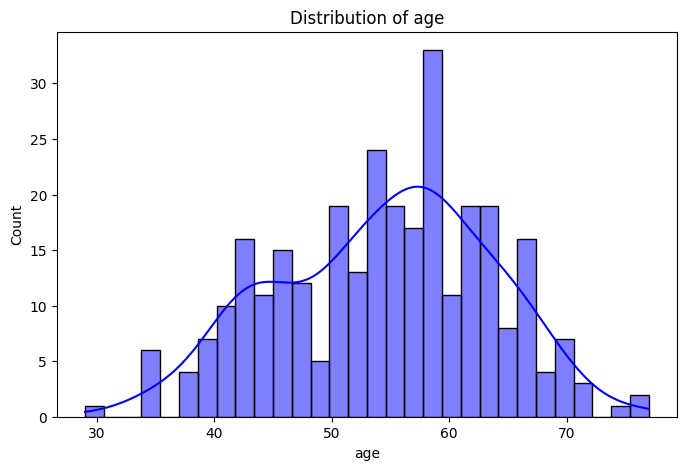

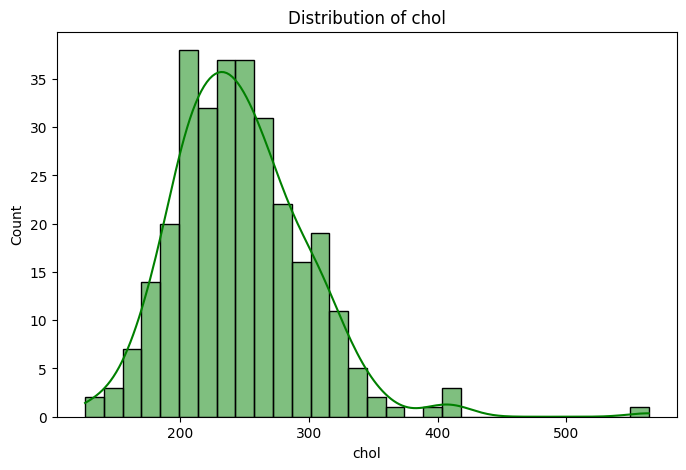

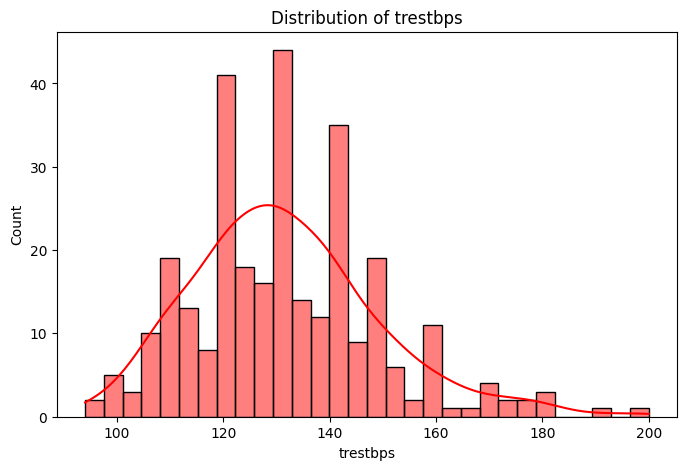


Skewness:
age        -0.203743
chol        1.147332
trestbps    0.716541
dtype: float64


In [22]:
columns = ["age", "chol", "trestbps"]
colors = ["blue", "green", "red"]

for i, col in enumerate(columns):
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], kde=True, bins=30, color=colors[i])
    plt.title("Distribution of " + col)
    plt.show()

print("\nSkewness:")
print(df[columns].skew())



## 4. OUTLIER DETECTION (Z-SCORE manually)

In [11]:
for col in columns:
    mean = df[col].mean()
    std = df[col].std()
    df["z_" + col] = (df[col] - mean) / std

outliers = df[(abs(df["z_age"]) > 3) |
              (abs(df["z_chol"]) > 3) |
              (abs(df["z_trestbps"]) > 3)]

print("\nNumber of Outliers:", outliers.shape[0])



Number of Outliers: 6


## 5. PROBABILITY CALCULATION

In [13]:
threshold = 240

high_chol = df[df["chol"] > threshold]
probability = high_chol["target"].mean()

print("\nProbability of Disease given Cholesterol >", threshold, "=", round(probability, 3))


Probability of Disease given Cholesterol > 240 = 0.477


## 6. CORRELATION HEATMAP

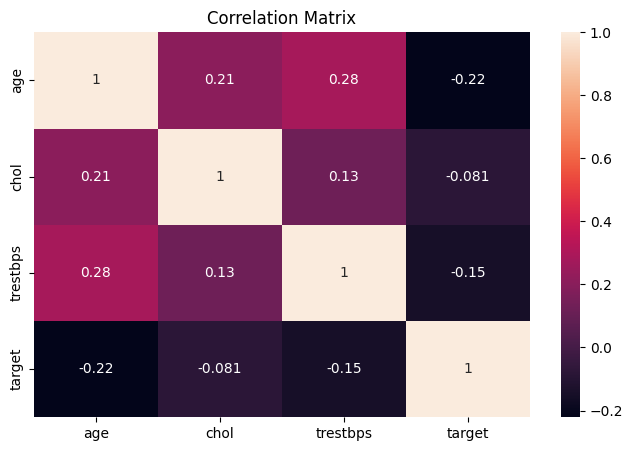

In [14]:
plt.figure(figsize=(8,5))
sns.heatmap(df[["age","chol","trestbps","target"]].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

## 7. CENTRAL LIMIT THEOREM (CLT)

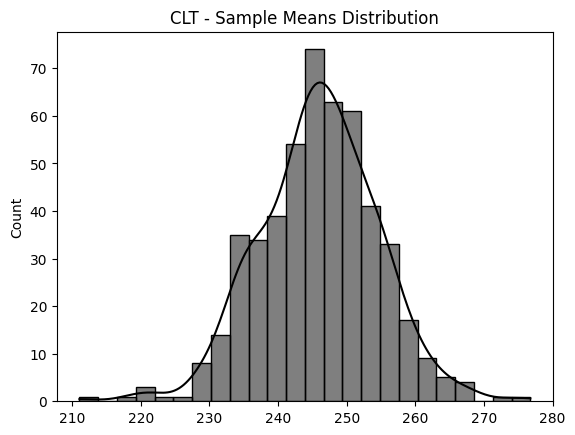

In [25]:
sample_means = []

for i in range(500):
    sample = df["chol"].sample(30)
    sample_means.append(sample.mean())

plt.figure()
sns.histplot(sample_means, kde=True, color="black")
plt.title("CLT - Sample Means Distribution")
plt.show()

## 8. GROUP MEAN COMPARISON

In [16]:
disease_mean = df[df["target"] == 1]["chol"].mean()
no_disease_mean = df[df["target"] == 0]["chol"].mean()

print("\nMean Cholesterol (Disease):", round(disease_mean,2))
print("Mean Cholesterol (No Disease):", round(no_disease_mean,2))



Mean Cholesterol (Disease): 242.64
Mean Cholesterol (No Disease): 251.09


## 9. SQLITE DATABASE

In [20]:
conn = sqlite3.connect("hospital.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS patients (
    age INTEGER,
    cholesterol REAL,
    blood_pressure REAL,
    disease INTEGER
)
""")

for _, row in df.head(50).iterrows():
    cursor.execute("""
INSERT INTO patients (age, cholesterol, blood_pressure, disease)
VALUES (?, ?, ?, ?)
""", (row["age"], row["chol"], row["trestbps"], row["target"]))


result = cursor.execute("""
SELECT AVG(disease)
FROM patients
WHERE cholesterol > ?
""", (threshold,)).fetchone()

print("\nSQL Probability:", round(result[0],3))

conn.close()



SQL Probability: 0.423


# OBSERVATIONS AND SOLUTIONS

1. Cholesterol is highly right-skewed (Skewness = 1.14).
Meaning: A significant number of patients have very high cholesterol levels.
Solution: Conduct regular lipid profile screenings and promote dietary & lifestyle interventions to reduce cardiovascular risk.

2. Resting Blood Pressure (trestbps) is moderately right-skewed (Skewness = 0.71).
Meaning: Some patients show elevated resting blood pressure levels.
Solution: Implement routine BP monitoring and early hypertension management programs.

3. Age distribution is approximately normal (Skewness = -0.20).
Meaning: Patients are fairly evenly distributed across age groups.
Solution: Focus preventive screening on middle-aged and elderly populations where risk increases.

4. Probability of disease increases when cholesterol > 240 mg/dL.
Meaning: High cholesterol patients show greater likelihood of heart disease.
Solution: Initiate early treatment plans, including medication and lifestyle changes for high-risk individuals.

5. Z-score analysis detected extreme outliers in cholesterol and blood pressure.
Meaning: Some patients fall into very high-risk categories.
Solution: Provide specialized medical attention and verify extreme readings to avoid diagnostic errors.